# Atelier Scikit-learn
Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, le bâtiment, la date et l'heure de la mesure.
Chaque mesure possède également un état (OK, ALERTE et ERREUR).
L'objectif de l'atelier est de construire un modèle capable de prédire automatiquement l'état d'un
capteur à partir de ses mesures.
L'atelier suivra le workflow classique du Machine Learning :
Dataset → Chargement → Exploration → Nettoyage → X / y → Train / Test → Prétraitement →
Modèle → fit()→ predict()→ Évaluation → Sauvegarde → Chargement → Réutilisation

## Partie 0 — Mise en place de l'environnement

**Objectif :** préparer l'environnement de travail et charger les données.

In [64]:
# pip install seaborn matplotlib pandas scikit-learn  (si nécessaire)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

sns.set_theme()
%matplotlib inline

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

### Import du dataset

In [65]:
df = pd.read_csv("../data/mesures_capteurs.csv", parse_dates=["date_heure"])
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### Exploration du DataFrame

In [66]:
print("Dimensions du data fram :", df.shape)
print("L'information du datafram ")
df.info()

Dimensions du data fram : (605, 9)
L'information du datafram 
<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    str           
 1   date_heure    605 non-null    datetime64[us]
 2   id_capteur    605 non-null    str           
 3   batiment      605 non-null    str           
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    str           
dtypes: datetime64[us](1), float64(4), str(4)
memory usage: 42.7 KB


In [67]:
df.describe()

,date_heure,temperature,humidite,pression,consommation
count,605,599.000000,600.00000,600.000000,600.000000
mean,2026-01-17 11:32:43.636363,24.878314,64.92620,1012.221900,208.675417
min,2026-01-05 00:00:00,-18.500000,28.52000,850.000000,18.120000
25%,2026-01-11 05:00:00,22.570000,58.17250,1006.790000,160.177500
50%,2026-01-17 12:00:00,24.860000,65.37500,1012.855000,206.150000
75%,2026-01-23 18:00:00,27.275000,71.61500,1017.827500,254.127500
max,2026-01-29 23:00:00,58.700000,145.00000,1038.430000,875.000000
std,NaN,4.059576,10.76905,10.599042,72.243567


In [68]:
df["etat"].value_counts()

etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64

**Constat :** le dataset contient 605 mesures. La variable cible `etat` est **fortement
déséquilibrée** : très majoritairement `OK` (567 mesures), avec seulement 29 `ALERTE` et 5 `ERREUR`.


## Partie 1 — Gestion des doublons

**Objectif :** un doublon (ligne strictement identique à une autre) fausserait l'entraînement en
donnant artificiellement plus de poids à certaines observations — il faut donc les détecter et les
supprimer avant toute étape de modélisation.

### 1) Vérifier l'existence de doublons

In [69]:
# .duplicated() renvoie True pour chaque ligne identique à une ligne précédente
# .sum() compte le nombre total de doublons détectés
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons détectés : {nb_doublons}")

Nombre de doublons détectés : 5


### 2) Supprimer les doublons puis vérifier

In [70]:
df = df.drop_duplicates()

print("Dimensions après suppression :", df.shape)
print("Doublons restants :", df.duplicated().sum())

Dimensions après suppression : (600, 9)
Doublons restants : 0


## Partie 2 — Sélection de y (cible) et X (caractéristiques)

**Objectif :** définir clairement ce que le modèle doit apprendre à prédire (`y`) et à partir de
quelles informations (`X`), conformément à la convention Scikit-learn.

**Remarque :** la colonne `etat` (notre cible) contient quelques valeurs
manquantes. Une ligne sans cible connue est inutilisable pour l'entraînement supervisé — on ne peut
pas imputer une cible (contrairement à une variable explicative), donc on retire ces lignes.

In [71]:
print("Valeurs manquantes dans 'etat' avant filtrage :", df["etat"].isna().sum())
df = df[df["etat"].notna()].reset_index(drop=True)
print("Dimensions après filtrage :", df.shape)

Valeurs manquantes dans 'etat' avant filtrage : 4
Dimensions après filtrage : (596, 9)


### 1) Définir X et y

In [72]:
features = ["temperature", "humidite", "pression", "consommation"]
target = "etat"

X = df[features].copy()
y = df[target].copy()

### 2) Afficher les cinq premières lignes de X et de y

In [73]:
x.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [74]:
y.head()

0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: str

### 3) Quel est le type du problème de Machine Learning ?
C'est un problème de **classification supervisée multi-classes** :
- **Supervisée**, car on dispose déjà des étiquettes (`etat`) pour entraîner le modèle.
- **Classification**, car la cible est catégorielle (pas une valeur numérique continue).
- **Multi-classes**, car il y a 3 classes possibles : `OK`, `ALERTE`, `ERREUR` (et non 2 seulement,
  ce qui serait une classification binaire).

## Partie 3 — Découpage Train/Test

**Objectif :** séparer les données en un ensemble d'entraînement et un ensemble de test, pour
évaluer le modèle sur des données qu'il n'a jamais vues.

In [75]:
from sklearn.model_selection import train_test_split

# test_size=0.2       -> 20% des données réservées au test
# random_state=42     -> graine aléatoire fixe, garantit un découpage reproductible d'une exécution à l'autre
# stratify=y          -> conserve les mêmes proportions de classes (OK/ALERTE/ERREUR) dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print()
print("Répartition des classes (train) :")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Répartition des classes (test) :")
print(y_test.value_counts(normalize=True).round(3))

Train : (476, 4) | Test : (120, 4)

Répartition des classes (train) :
etat
OK        0.943
ALERTE    0.048
ERREUR    0.008
Name: proportion, dtype: float64

Répartition des classes (test) :
etat
OK        0.942
ALERTE    0.050
ERREUR    0.008
Name: proportion, dtype: float64


On vérifie bien que `stratify=y` a fonctionné : les proportions de `OK`/`ALERTE`/`ERREUR` sont
quasiment identiques entre le train et le test — indispensable avec des classes aussi déséquilibrées,
sinon la classe `ERREUR` (déjà rare) pourrait se retrouver quasi absente du test.

## Partie 4 — Gestion des valeurs manquantes

**Objectif :** les algorithmes de Scikit-learn ne fonctionnent pas avec des `NaN` — il faut donc
les remplacer par une valeur cohérente avant d'entraîner le modèle.

### 1) Vérifier l'existence de valeurs manquantes

In [76]:
print("Valeurs manquantes dans X_train :")
print(X_train.isna().sum())
print()
print("Valeurs manquantes dans X_test :")
print(X_test.isna().sum())

Valeurs manquantes dans X_train :
temperature     5
humidite        4
pression        5
consommation    3
dtype: int64

Valeurs manquantes dans X_test :
temperature     1
humidite        1
pression        0
consommation    2
dtype: int64


### 2) Sélectionner SimpleImputer avec la médiane

In [77]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

### 3) Qu'est-ce qui justifie le choix de la médiane ?
La **médiane** est robuste aux valeurs extrêmes (outliers), contrairement à la **moyenne** qui est
fortement tirée par elles. Or on a déjà observé, lors de l'atelier Seaborn, des valeurs de
température aberrantes (ex. -18,5°C ou 58,7°C) et d'autres anomalies (humidité > 100%, pression très
basse). Utiliser la moyenne pour imputer ces colonnes serait faussé par ces extrêmes ; la médiane
donne une estimation plus fiable de la « valeur typique » d'un capteur.

### 4) Calibrer l'imputer sur X_train

In [78]:
# fit() calcule les médianes de chaque colonne UNIQUEMENT à partir de X_train
# (jamais à partir de X_test, pour éviter toute fuite de données)
imputer.fit(X_train)

print("Médianes apprises (une par variable) :")
for col, mediane in zip(features, imputer.statistics_):
    print(f"  {col} : {mediane:.2f}")

Médianes apprises (une par variable) :
  temperature : 24.90
  humidite : 65.38
  pression : 1012.30
  consommation : 206.59


### 5) Déterminer X_train_imputed et X_test_imputed

In [79]:
# transform() applique les médianes apprises sur le train aux deux ensembles
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=features, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=features, index=X_test.index)

print("Valeurs manquantes restantes (train) :", X_train_imputed.isna().sum().sum())
print("Valeurs manquantes restantes (test)  :", X_test_imputed.isna().sum().sum())

Valeurs manquantes restantes (train) : 0
Valeurs manquantes restantes (test)  : 0


## Partie 5 — Mise à l'échelle

**Objectif :** ramener toutes les variables sur une échelle comparable, indispensable pour les
algorithmes basés sur des distances (comme KNN, utilisé en Partie 6).

### 1) Sélectionner StandardScaler

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

### 2) Qu'est-ce qui justifie la standardisation ?
Nos 4 variables ont des échelles très différentes : `pression` varie autour de 1000 (hPa), alors que
`temperature` varie autour de 25 (°C) et `humidite` autour de 60 (%). Un algorithme basé sur des
distances comme **KNN** calculerait alors une distance dominée presque entièrement par la pression,
simplement parce que ses valeurs sont numériquement plus grandes — pas parce qu'elle est plus
importante. La standardisation (moyenne = 0, écart-type = 1) met toutes les variables sur un pied
d'égalité.

### 3) Calibrer le scaler sur X_train_imputed

In [81]:
scaler.fit(X_train_imputed)

print("Moyennes apprises :")
for col, moyenne in zip(features, scaler.mean_):
    print(f"  {col} : {moyenne:.2f}")

print()
print("Écarts-types appris :")
for col, ecart_type in zip(features, scaler.scale_):
    print(f"  {col} : {ecart_type:.2f}")

Moyennes apprises :
  temperature : 24.96
  humidite : 64.85
  pression : 1012.08
  consommation : 210.15

Écarts-types appris :
  temperature : 4.19
  humidite : 10.16
  pression : 10.99
  consommation : 73.42


### 4) Déterminer X_train_scaled et X_test_scaled

In [82]:
X_train_scaled = pd.DataFrame(scaler.transform(X_train_imputed), columns=features, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=features, index=X_test_imputed.index)

X_train_scaled.describe().loc[["mean", "std"]].round(2)
# Vérification : après standardisation, chaque colonne du train doit avoir une moyenne ≈ 0 et un écart-type ≈ 1

,temperature,humidite,pression,consommation
mean,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0


## Partie 6 — Entraînement et prédiction d'un modèle

**Objectif :** entraîner un modèle **KNN (k plus proches voisins)** : pour prédire l'état d'une
nouvelle mesure, l'algorithme regarde les `k` mesures les plus proches (au sens de la distance
euclidienne, sur les variables standardisées) déjà connues, et vote pour la classe majoritaire parmi
elles.

### 1) Sélectionner le modèle KNN avec k=5

In [83]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

### 2) Entraîner le modèle

In [84]:
knn.fit(X_train_scaled, y_train)
print("Modèle entraîné :", knn)

Modèle entraîné : KNeighborsClassifier()


### 3) Prédire sur l'ensemble de test

In [85]:
y_pred = knn.predict(X_test_scaled)
print("Nombre de prédictions :", len(y_pred))

Nombre de prédictions : 120


### 4) Afficher quelques prédictions

In [86]:
y_pred[:15]

array(['OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK',
       'OK', 'OK', 'OK', 'OK'], dtype=object)

### 5) Comparer prédictions et vraies valeurs

In [87]:
comparaison = pd.DataFrame({
    "valeur_reelle": y_test.values,
    "valeur_predite": y_pred,
})
comparaison["correct"] = comparaison["valeur_reelle"] == comparaison["valeur_predite"]
comparaison.head(15)

,valeur_reelle,valeur_predite,correct
0,OK,OK,True
1,OK,OK,True
2,OK,OK,True
3,OK,OK,True
4,ALERTE,OK,False
5,OK,OK,True
6,OK,OK,True
7,OK,OK,True
8,OK,OK,True
9,OK,OK,True


In [88]:
print("Prédictions correctes :", comparaison['correct'].sum(), "/", len(comparaison))

Prédictions correctes : 115 / 120


## Partie 7 – Evaluation du modèle


### 1) Évaluer avec Accuracy

In [89]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.2%}")

Accuracy : 95.83%


### 2) Pourquoi l'accuracy ne suffit-elle pas toujours ?
Parce que nos classes sont **très déséquilibrées** (≈94% de `OK`, ≈5% d'`ALERTE`, ≈1% d'`ERREUR`).
Un modèle « paresseux » qui prédirait **toujours `OK`**, sans rien apprendre, obtiendrait déjà une
accuracy proche de 94% — un chiffre trompeusement élevé, alors qu'il serait totalement incapable de
détecter une alerte ou une erreur, ce qui est pourtant l'objectif principal de ce modèle en
pratique. Il faut donc regarder des métriques **par classe** (matrice de confusion, precision,
recall, F1-score) pour juger si le modèle détecte réellement les cas rares et critiques.

### 3) Matrice de confusion

In [90]:
from sklearn.metrics import confusion_matrix

classes = sorted(y.unique())  # ordre cohérent des classes : ALERTE, ERREUR, OK
cm = confusion_matrix(y_test, y_pred, labels=classes)

cm_df = pd.DataFrame(cm, index=[f"Réel: {c}" for c in classes], columns=[f"Prédit: {c}" for c in classes])
cm_df

,Prédit: ALERTE,Prédit: ERREUR,Prédit: OK
Réel: ALERTE,2,0,4
Réel: ERREUR,1,0,0
Réel: OK,0,0,113


**Commentaire :** chaque ligne représente la vraie classe, chaque colonne la classe prédite. La
diagonale montre les prédictions correctes. On peut s'attendre à ce que la classe `OK` soit très bien
prédite (beaucoup d'exemples pour apprendre), alors que `ALERTE` et surtout `ERREUR` (très peu
d'exemples dans le train) sont plus difficiles à détecter correctement pour le modèle — certaines
mesures `ALERTE` ou `ERREUR` risquent d'être classées à tort comme `OK`.

### 4) Visualiser la matrice de confusion avec Seaborn

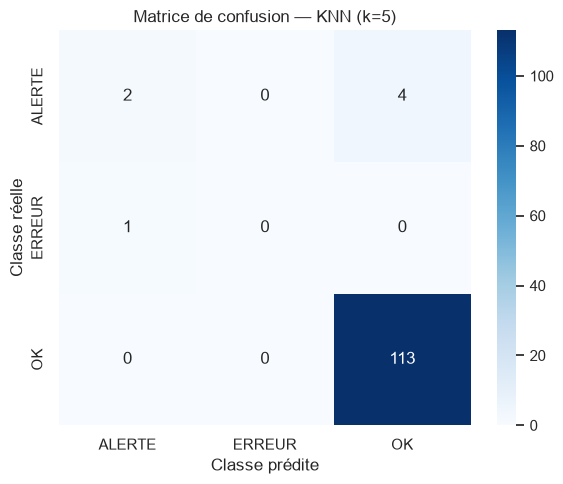

In [91]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Matrice de confusion — KNN (k=5)")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

### 5) Rapport de classification

In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, labels=classes))

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

**Commentaire :** le rapport détaille, pour chaque classe, la **precision** (parmi les mesures
prédites dans cette classe, combien le sont réellement), le **recall** (parmi les mesures réellement
dans cette classe, combien le modèle en a retrouvé), et le **F1-score** (moyenne harmonique des deux).
On s'attend à des scores élevés pour `OK` (classe majoritaire, bien représentée), et des scores plus
faibles ou plus instables pour `ALERTE`/`ERREUR`, faute d'exemples suffisants pour bien les apprendre.
La colonne `support` rappelle le nombre réel d'exemples de chaque classe dans le test — à lire en
priorité pour interpréter la fiabilité de chaque score.

### 6) Quelle métrique privilégier selon le contexte ?

| Métrique | Ce qu'elle mesure | Cas où elle est la plus indiquée |
|---|---|---|
| **Precision** | Parmi les alertes prédites, combien sont de vraies alertes ? | Quand le coût d'une **fausse alerte** est élevé (ex. une intervention technique coûteuse déclenchée pour rien) |
| **Recall** | Parmi les vraies alertes, combien sont détectées ? | Quand **manquer un cas critique** est inacceptable (ex. rater une `ERREUR` capteur = panne non détectée, risque pour le bâtiment) |
| **F1-score** | Équilibre entre precision et recall | Quand il faut un **compromis** entre les deux, notamment sur des classes rares comme `ALERTE`/`ERREUR` |
| **Accuracy** | Proportion totale de bonnes prédictions | Uniquement quand les classes sont **équilibrées** — ici elle est trompeuse à cause du déséquilibre `OK` vs `ALERTE`/`ERREUR` |

Dans notre contexte IoT (détecter des pannes de capteurs), le **recall** sur les classes `ALERTE` et
`ERREUR` est probablement la métrique la plus critique : mieux vaut quelques fausses alertes
(precision imparfaite) que de rater une vraie panne (recall trop bas).

## Partie 8 — Sauvegarde du modèle

**Objectif :** conserver le modèle entraîné pour le réutiliser sans avoir à le réentraîner.

### 1) Sauvegarder avec Joblib


In [94]:
import joblib

joblib.dump(knn, f"{MODELS_DIR}/modele_capteurs.joblib")
print("Modèle sauvegardé :", f"{MODELS_DIR}/modele_capteurs.joblib")

Modèle sauvegardé : ../models/modele_capteurs.joblib


### 2) Sauvegarder avec Pickle

In [95]:
import pickle

with open(f"{MODELS_DIR}/modele_capteurs.pkl", "wb") as f:
    pickle.dump(knn, f)
print("Modèle sauvegardé :", f"{MODELS_DIR}/modele_capteurs.pkl")

Modèle sauvegardé : ../models/modele_capteurs.pkl


## Partie 9 — Chargement du modèle

**Objectif :** vérifier qu'on peut recharger le modèle sauvegardé et l'utiliser immédiatement pour
prédire, sans repasser par l'entraînement.

### 1) Charger le modèle

In [96]:
knn_recharge = joblib.load(f"{MODELS_DIR}/modele_capteurs.joblib")
print("Modèle rechargé :", knn_recharge)

Modèle rechargé : KNeighborsClassifier()


### 2) Prédire avec une nouvelle mesure

In [97]:
# Nouvelle mesure fictive : température et consommation élevées -> potentiellement suspect
nouvelle_mesure = pd.DataFrame([{
    "temperature": 42.0,
    "humidite": 65.0,
    "pression": 1005.0,
    "consommation": 310.0,
}])

#  Il faut appliquer EXACTEMENT le même prétraitement que pour l'entraînement :
# d'abord l'imputation (ici sans effet, pas de NaN), puis la standardisation
nouvelle_mesure_imputed = pd.DataFrame(imputer.transform(nouvelle_mesure), columns=features)
nouvelle_mesure_scaled = pd.DataFrame(scaler.transform(nouvelle_mesure_imputed), columns=features)

prediction = knn_recharge.predict(nouvelle_mesure_scaled)
probabilites = knn_recharge.predict_proba(nouvelle_mesure_scaled)

print("État prédit :", prediction[0])
print("Probabilités par classe :")
for classe, proba in zip(knn_recharge.classes_, probabilites[0]):
    print(f"  {classe} : {proba:.2%}")

État prédit : OK
Probabilités par classe :
  ALERTE : 40.00%
  ERREUR : 0.00%
  OK : 60.00%


## Partie 10 — Bonus

**Fonctionnalité proposée : recherche du meilleur nombre de voisins (k) pour KNN**, via une
validation croisée, plutôt que de fixer k=5 arbitrairement. On compare aussi l'accuracy avec le
**F1-score macro** (moyenne du F1 sur les 3 classes, sans pondération par leur taille) — plus adapté
que l'accuracy pour un jeu déséquilibré comme celui-ci.

In [98]:
from sklearn.model_selection import cross_val_score

valeurs_k = range(1, 16)
scores_f1_macro = []

for k in valeurs_k:
    modele_k = KNeighborsClassifier(n_neighbors=k)
    # cv=5 : validation croisée à 5 plis sur le train, plus fiable qu'un seul découpage train/test
    scores = cross_val_score(modele_k, X_train_scaled, y_train, cv=5, scoring="f1_macro")
    scores_f1_macro.append(scores.mean())

resultats_k = pd.DataFrame({"k": list(valeurs_k), "f1_macro_moyen": scores_f1_macro})
meilleur_k = resultats_k.loc[resultats_k["f1_macro_moyen"].idxmax(), "k"]
print(f"Meilleur k trouvé : {meilleur_k}")
resultats_k

C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packa

Meilleur k trouvé : 2


C:\Users\abdou\Desktop\GROUP 1 ODC\ATELIER SCIKIT-LEARN\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


,k,f1_macro_moyen
0,1,0.488799
1,2,0.526106
2,3,0.433893
3,4,0.433517
4,5,0.403160
5,6,0.403160
6,7,0.383408
7,8,0.383756
8,9,0.356036
9,10,0.356388


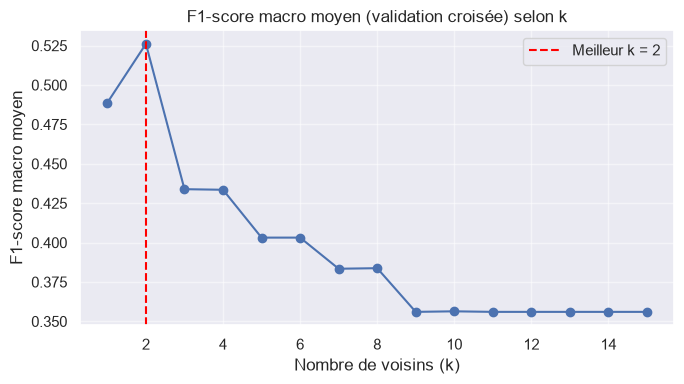

In [99]:
plt.figure(figsize=(7, 4))
plt.plot(resultats_k["k"], resultats_k["f1_macro_moyen"], marker="o")
plt.axvline(meilleur_k, color="red", linestyle="--", label=f"Meilleur k = {meilleur_k}")
plt.title("F1-score macro moyen (validation croisée) selon k")
plt.xlabel("Nombre de voisins (k)")
plt.ylabel("F1-score macro moyen")
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

- Le modèle KNN (k=5) atteint une bonne accuracy globale, portée par la classe majoritaire `OK`.
- La matrice de confusion et le rapport de classification révèlent que les classes rares
  (`ALERTE`, `ERREUR`) sont plus difficiles à détecter — logique vu leur faible représentation dans
  les données d'entraînement.
- Dans un contexte de maintenance IoT, le **recall** sur `ALERTE`/`ERREUR` est la métrique à
  surveiller en priorité : rater une panne coûte plus cher qu'une fausse alerte.
- Le modèle est sauvegardé (Joblib + Pickle) et rechargé avec succès pour une prédiction en
  conditions réelles sur une nouvelle mesure.
